# Adjusted Factor Backtest Comparison

This notebook visualises adjusted backtest summaries stored in
`factor_report/<factor_name>/adjust_backtest/adjust_summary.json`.

In [5]:
# Imports and configuration
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

FACTOR_NAME = "cnn_10_03_72h_v4_wma_10h_0.4"  # update with the desired factor
BASE_DIR = Path.cwd()
SUMMARY_PATH = BASE_DIR / "factor_report" / FACTOR_NAME / "adjust_backtest" / "adjust_summary.json"

SUMMARY_PATH

PosixPath('/home/craz/crypto/crypto-trading/strategy/backtest/factor_report/cnn_10_03_72h_v4_wma_10h_0.4/adjust_backtest/adjust_summary.json')

In [6]:
# Load summary data and create a dataframe per strategy
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Summary file not found: {SUMMARY_PATH}")

with SUMMARY_PATH.open("r", encoding="utf-8") as handle:
    data = json.load(handle)

strategies = data.get("strategies", {})
rows = []
for strategy, payload in strategies.items():
    overall = payload.get("overall", {})
    metrics = overall.get("metrics", {})
    rows.append({
        "strategy": strategy,
        "count": overall.get("count", 0),
        "return_mean": metrics.get("total_return", {}).get("mean", np.nan),
        "return_variance": metrics.get("total_return", {}).get("variance", np.nan),
        "sharpe_mean": metrics.get("sharpe_ratio", {}).get("mean", np.nan),
        "win_rate_mean": metrics.get("win_rate", {}).get("mean", np.nan),
        "max_drawdown_mean": metrics.get("max_drawdown", {}).get("mean", np.nan),
    })

summary_df = pd.DataFrame(rows)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


summary_df

,strategy,count,return_mean,return_variance,sharpe_mean,win_rate_mean,max_drawdown_mean
0,lev_3_backtest_no_stopprofit,16,1.286972,3.563246,1.670003,0.544524,-0.610969
1,lev_3_backtest_profit_0_stop_20,16,1.263899,3.339640,1.575921,0.526549,-0.553025
2,lev_3_backtest_profit_0_stop_30,16,1.664280,4.407114,1.867386,0.537334,-0.546235
3,lev_3_backtest_profit_0_stop_40,16,1.707473,5.654205,1.832287,0.541482,-0.552748
4,lev_3_backtest_profit_20_stop_0,16,1.523470,6.345708,1.798427,0.553097,-0.582123
5,lev_3_backtest_profit_20_stop_20,16,1.331628,3.624452,1.683138,0.532356,-0.523979
6,lev_3_backtest_profit_20_stop_30,16,1.687036,3.887695,1.991125,0.545907,-0.528881
7,lev_3_backtest_profit_20_stop_40,16,1.728907,4.357016,1.974522,0.550055,-0.536989
8,lev_3_backtest_profit_40_stop_0,16,1.372436,3.766665,1.757075,0.545354,-0.592472
9,lev_3_backtest_profit_40_stop_20,16,1.242307,2.703954,1.638275,0.527655,-0.540252


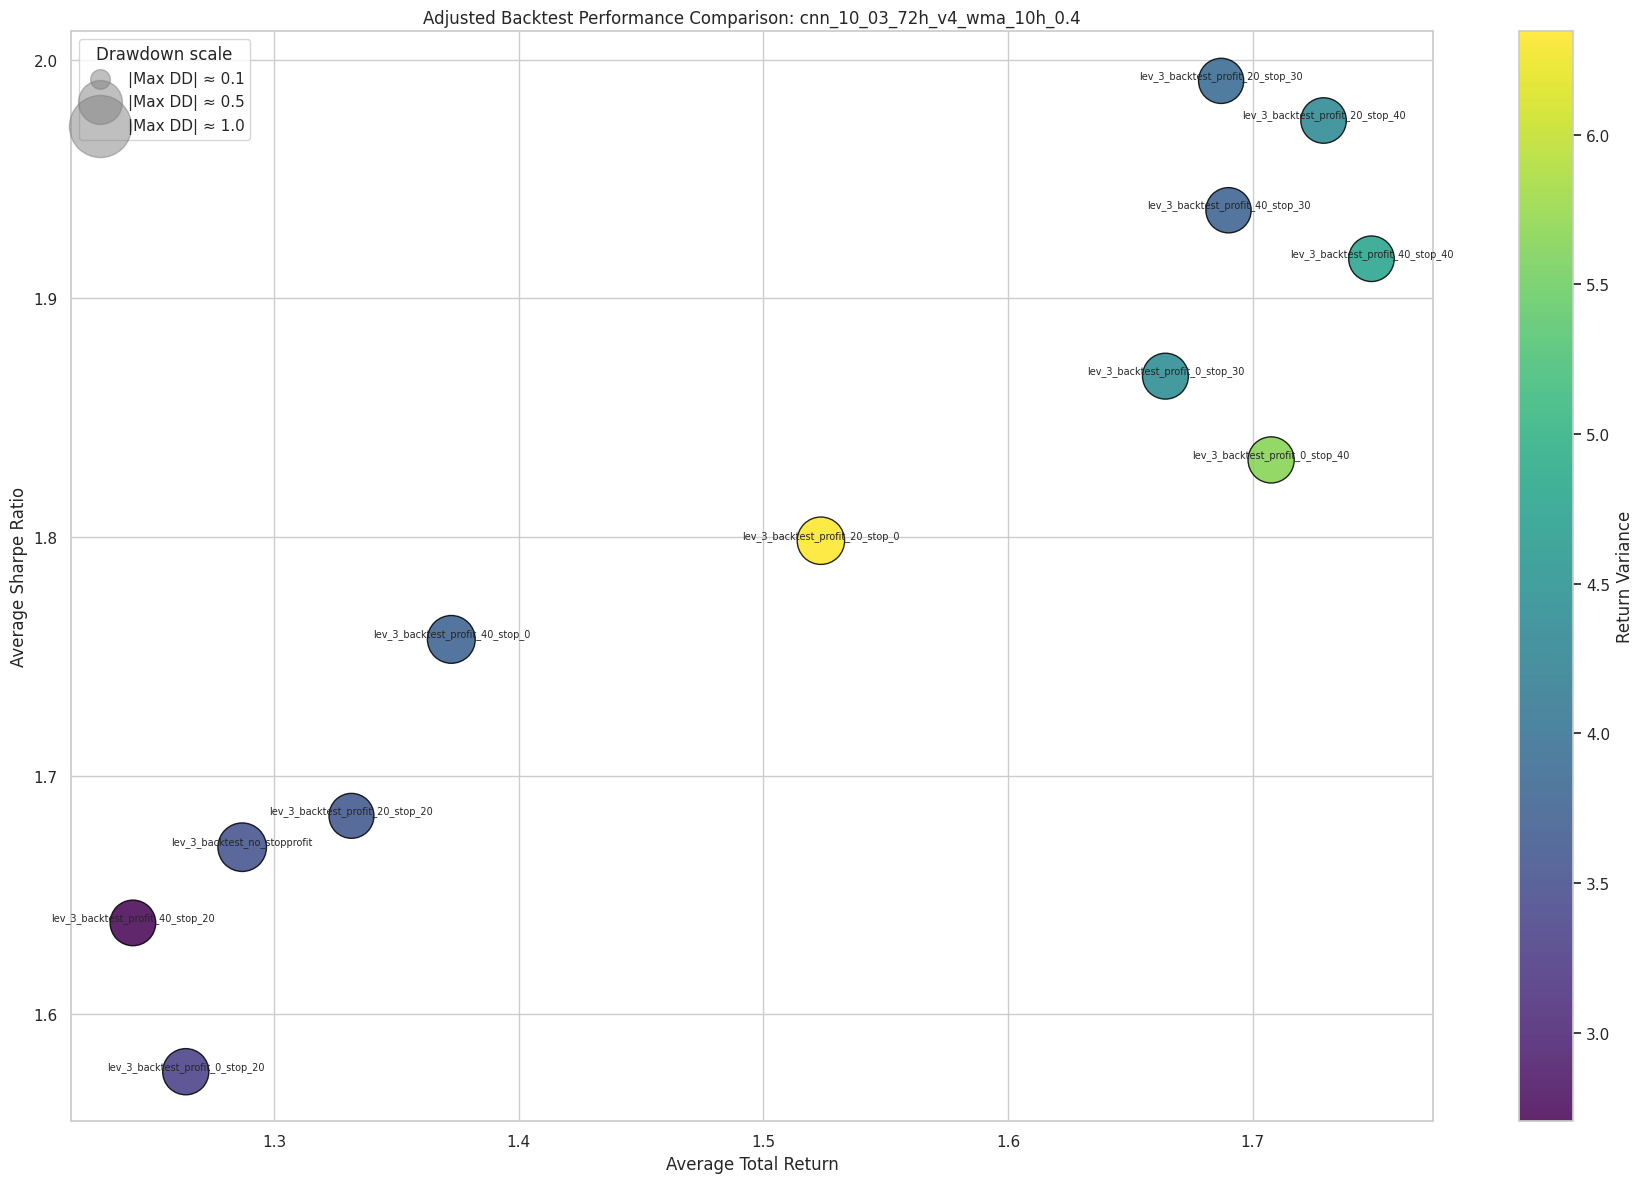

In [7]:
# Scatter plot: return mean vs sharpe mean
if summary_df.empty:
    raise ValueError("No strategy data available for plotting.")

size_scale = 2000
sizes = summary_df["max_drawdown_mean"].abs().fillna(0) * size_scale

plt.figure(figsize=(18, 12))
scatter = plt.scatter(
    summary_df["return_mean"],
    summary_df["sharpe_mean"],
    c=summary_df["return_variance"],
    s=sizes,
    cmap="viridis",
    alpha=0.85,
    edgecolor="black"
)

for idx, row in summary_df.iterrows():
    plt.text(
        row["return_mean"],
        row["sharpe_mean"],
        row["strategy"],
        fontsize=7,
        ha="center",
        va="bottom"
    )

plt.xlabel("Average Total Return")
plt.ylabel("Average Sharpe Ratio")
plt.title(f"Adjusted Backtest Performance Comparison: {FACTOR_NAME}")

cbar = plt.colorbar(scatter)
cbar.set_label("Return Variance")

for drawdown_level in [0.1, 0.5, 1]:
    plt.scatter(
        [], [],
        s=drawdown_level * size_scale,
        c="grey",
        alpha=0.5,
        label=f"|Max DD| ≈ {drawdown_level:.1f}"
    )

plt.legend(scatterpoints=1, frameon=True, title="Drawdown scale")
plt.tight_layout()
plt.show()